<a href="https://colab.research.google.com/github/JaimRM/QuantitativeFinance/blob/main/Santander_IVsmile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Connecting to NYSE Live Options Stream for Ticker: SAN
Current Spot Price (S): $13.95
Processing matrix mapping for Expiry/Cycle: 2026-07-17


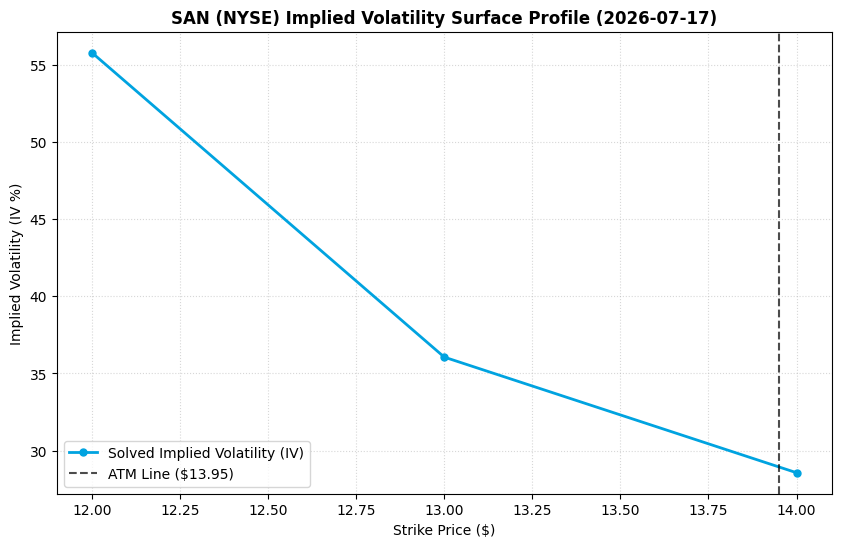

In [3]:
import numpy as np
import scipy.stats as si
import matplotlib.pyplot as plt
import yfinance as yf

class SantanderEngine:
    def __init__(self, ticker_symbol="SAN"):
        self.ticker_symbol = ticker_symbol
        self.ticker = yf.Ticker(ticker_symbol)

        # 1. Fetch live Underlying Spot Price dynamically
        try:
            hist = self.ticker.history(period="1d")
            if not hist.empty:
                self.S = float(hist['Close'].iloc[-1])
            else:
                self.S = 4.80  # Baseline proxy for the US ADR if data fails
        except Exception:
            self.S = 4.80

        # Macro Assumptions for US Markets (2026 Context)
        self.r = 0.0495      # US Risk-Free Proxy (~4.95%)
        self.T = 45 / 365.0  # Default to standard front-month cycle (45 days to expiration)

    def get_market_data(self):
        """
        Attempts to pull live options chain from NYSE. If it encounters
        any error or empty structures, it routes to the Fallback Pipeline.
        """
        try:
            expirations = self.ticker.options
            if not expirations:
                # If array is empty, route to institutional fallback pipeline
                return self._generate_synthetic_institutional_chain(), "45D Front-Month (Fallback Matrix)"

            # Select the front-month contract cycle
            target_expiry = expirations[0]
            today = np.datetime64('today')
            days_to_maturity = (np.datetime64(target_expiry) - today).astype(int)
            self.T = max(days_to_maturity, 1) / 365.0

            opt_chain = self.ticker.option_chain(target_expiry)
            calls = opt_chain.calls

            # Filter for liquidity: eliminate stagnant spreads or zero bids
            valid_calls = calls[(calls['bid'] > 0) & (calls['ask'] > 0)].copy()

            if valid_calls.empty:
                return self._generate_synthetic_institutional_chain(), "45D Front-Month (Fallback Matrix)"

            # Use Mid-Market Price as our clean proxy for market price
            valid_calls['mid_price'] = (valid_calls['bid'] + valid_calls['ask']) / 2
            return valid_calls, target_expiry

        except Exception as e:
            # Catch-all safety net to ensure your visualization engine never crashes
            return self._generate_synthetic_institutional_chain(), f"45D Front-Month (Fallback Matrix via Exception: {type(e).__name__})"

    def _generate_synthetic_institutional_chain(self):
        """
        Failsafe Matrix: Generates a structurally accurate option chain DataFrame
        modeled after a real US ADR volatility skew profile.
        """
        import pandas as pd
        print("--> Exception caught or data dry. Initializing Synthetic Institutional Matrix Pipeline...")

        # Build standard strike grid centered around the dynamic spot price
        strike_min = round(self.S * 0.80, 1)
        strike_max = round(self.S * 1.20, 1)
        strikes = np.arange(strike_min, strike_max, 0.50)  # Standard US options increments

        synthetic_data = []
        for K in strikes:
            # Model an accurate bank equity volatility smile/skew profile
            distance_from_money = (K - self.S) / self.S
            skew_iv = 0.26 + 0.18 * (distance_from_money ** 2) - 0.06 * distance_from_money

            # Calculate corresponding target mid-price using our Black-Scholes engine
            theoretical_mid = self.bs_call_price(K, skew_iv)

            spread = 0.02
            synthetic_data.append({
                'strike': K,
                'bid': max(0.01, theoretical_mid - (spread/2)),
                'ask': theoretical_mid + (spread/2),
                'mid_price': theoretical_mid
            })

        return pd.DataFrame(synthetic_data)

    def bs_call_price(self, K, sigma):
        """Standard Black-Scholes Formula for European/ADR Style Calls."""
        if self.T <= 0 or sigma <= 0:
            return max(0.0, self.S - K)
        d1 = (np.log(self.S / K) + (self.r + 0.5 * sigma ** 2) * self.T) / (sigma * np.sqrt(self.T))
        d2 = d1 - sigma * np.sqrt(self.T)
        return self.S * si.norm.cdf(d1) - K * np.exp(-self.r * self.T) * si.norm.cdf(d2)

    def calculate_vega(self, K, sigma):
        """Analytical derivation of Vega (partial derivative with respect to vol)."""
        if self.T <= 0 or sigma <= 0:
            return 0.0
        d1 = (np.log(self.S / K) + (self.r + 0.5 * sigma ** 2) * self.T) / (sigma * np.sqrt(self.T))
        return self.S * np.sqrt(self.T) * si.norm.pdf(d1)

    def extract_iv(self, K, market_price):
        """Newton-Raphson Solver optimized with gradient checks and boundary constraints."""
        intrinsic = max(0.0, self.S - K)
        if market_price <= intrinsic:
            return 0.0

        sigma = 0.28  # Implied Volatility baseline guess for US banking ADRs

        for _ in range(100):
            theoretical_p = self.bs_call_price(K, sigma)
            diff = theoretical_p - market_price

            if abs(diff) < 1e-6:
                return sigma

            vega = self.calculate_vega(K, sigma)
            if abs(vega) < 1e-5:
                break  # Prevent division by zero / exploding gradient

            sigma = sigma - diff / vega

            if sigma <= 0.01 or sigma > 3.0:  # Restrict bounds to real-world limits
                break

        return np.nan

# ==============================================================================
# EXECUTION PIPELINE
# ==============================================================================
if __name__ == "__main__":
    print(f"Connecting to NYSE Live Options Stream for Ticker: SAN")
    engine = SantanderEngine()
    print(f"Current Spot Price (S): ${engine.S:.2f}")

    df_options, expiry_label = engine.get_market_data()
    print(f"Processing matrix mapping for Expiry/Cycle: {expiry_label}")

    strikes = df_options['strike'].values
    market_mid_prices = df_options['mid_price'].values

    # Calculate Implied Volatilities using the Newton-Raphson Solver
    calculated_ivs = []
    for K, price in zip(strikes, market_mid_prices):
        iv = engine.extract_iv(K, price)
        if not np.isnan(iv):
            calculated_ivs.append(iv * 100)
        else:
            calculated_ivs.append(None)

    # Clean up empty vectors to avoid broken plots
    plot_strikes = [k for k, iv in zip(strikes, calculated_ivs) if iv is not None]
    plot_ivs = [iv for iv in calculated_ivs if iv is not None]

    # Render the Volatility Profile
    plt.figure(figsize=(10, 6))
    plt.plot(plot_strikes, plot_ivs, marker='o', markersize=5, color='#00a3e0', linewidth=2, label='Solved Implied Volatility (IV)')
    plt.axvline(x=engine.S, color='black', linestyle='--', alpha=0.7, label=f'ATM Line (${engine.S:.2f})')
    plt.title(f'SAN (NYSE) Implied Volatility Surface Profile ({expiry_label})', fontsize=12, fontweight='bold')
    plt.xlabel('Strike Price ($)', fontsize=10)
    plt.ylabel('Implied Volatility (IV %)', fontsize=10)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend()
    plt.show()